In [9]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error
from mpl_toolkits.mplot3d import Axes3D

In [30]:
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

print("Форма X:", X.shape)
print("Форма y:", y.shape)
print("Унікальні мітки:", np.unique(y))

Форма X: (70000, 784)
Форма y: (70000,)
Унікальні мітки: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


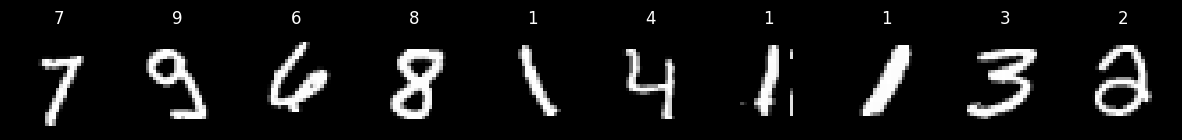

In [31]:
indices = np.random.choice(len(X), 10)

fig, axes = plt.subplots(1, 10, figsize=(15, 3))

for i, idx in enumerate(indices):
    axes[i].imshow(X[idx].reshape(28, 28), cmap="gray")
    axes[i].set_title(f"{y[idx]}")
    axes[i].axis("off")

plt.show()

In [12]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

print("Розмірність після PCA:", X_pca.shape)
print("Пояснена дисперсія кожної компоненти:")
print(pca.explained_variance_ratio_)
print("Сумарна пояснена дисперсія:")
print(np.sum(pca.explained_variance_ratio_))

Розмірність після PCA: (70000, 3)
Пояснена дисперсія кожної компоненти:
[0.09746116 0.07155445 0.06149531]
Сумарна пояснена дисперсія:
0.2305109149009649


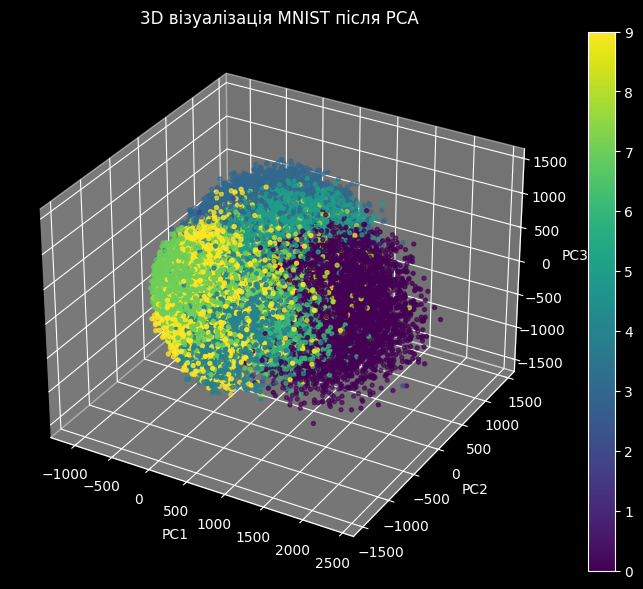

In [22]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    X_pca[:, 2],
    c=y.astype(int),
    s=8
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_title("3D візуалізація MNIST після PCA")

plt.colorbar(scatter)
plt.show()

In [14]:
X_reconstructed = pca.inverse_transform(X_pca)

print("Форма реконструйованих даних:", X_reconstructed.shape)

Форма реконструйованих даних: (70000, 784)


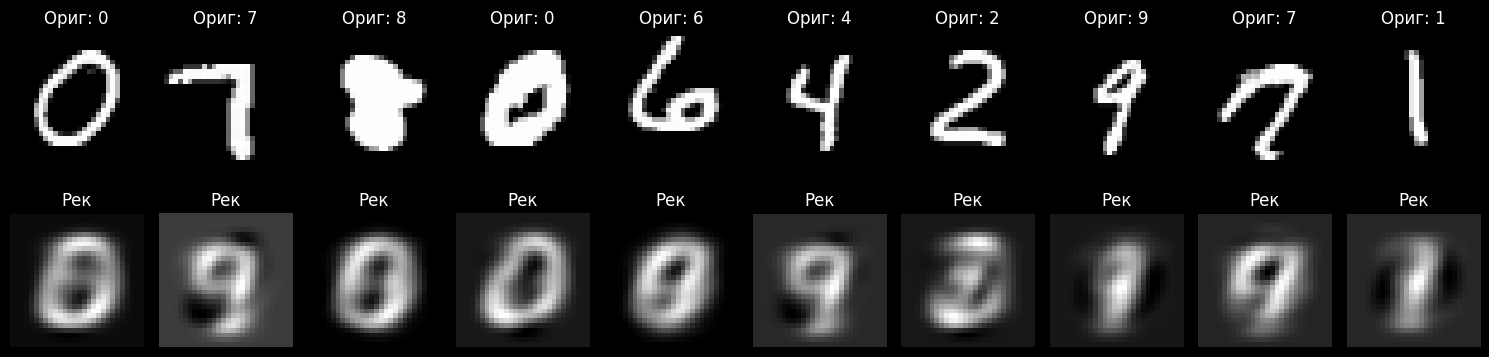

In [33]:
indices = np.random.choice(len(X), 10)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))

for i, idx in enumerate(indices):
    # Оригінал
    axes[0, i].imshow(X[idx].reshape(28, 28), cmap="gray")
    axes[0, i].set_title(f"Ориг: {y[idx]}")
    axes[0, i].axis("off")

    # Реконструкція
    axes[1, i].imshow(X_reconstructed[idx].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Рек")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [16]:
mse_3 = mean_squared_error(X, X_reconstructed)
print("MSE для 3 компонент:", mse_3)

MSE для 3 компонент: 3366.489667994886


In [34]:
components_list = [2, 5, 10, 20, 30, 50, 100, 200]

mse_list = []
variance_list = []

for k in components_list:
    pca_k = PCA(n_components=k)
    X_pca_k = pca_k.fit_transform(X)
    X_rec_k = pca_k.inverse_transform(X_pca_k)

    # MSE
    mse = mean_squared_error(X, X_rec_k)

    # explained variance
    variance = np.sum(pca_k.explained_variance_ratio_)

    mse_list.append(mse)
    variance_list.append(variance)

    print(f"k = {k}")
    print(f"MSE = {mse:.6f}")
    print(f"Explained variance = {variance:.6f}")
    print("-" * 30)

k = 2
MSE = 3635.529644
Explained variance = 0.169016
------------------------------
k = 5
MSE = 2916.204100
Explained variance = 0.333434
------------------------------
k = 10
MSE = 2234.862667
Explained variance = 0.489170
------------------------------
k = 20
MSE = 1554.396207
Explained variance = 0.644707
------------------------------
k = 30
MSE = 1174.099910
Explained variance = 0.731632
------------------------------
k = 50
MSE = 763.786890
Explained variance = 0.825419
------------------------------
k = 100
MSE = 372.018316
Explained variance = 0.914967
------------------------------
k = 200
MSE = 146.388422
Explained variance = 0.966540
------------------------------


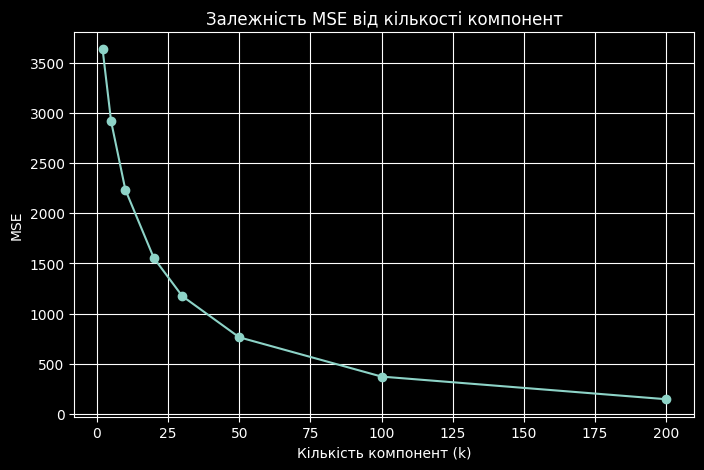

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(components_list, mse_list, marker='o')
plt.xlabel("Кількість компонент (k)")
plt.ylabel("MSE")
plt.title("Залежність MSE від кількості компонент")
plt.grid(True)
plt.show()

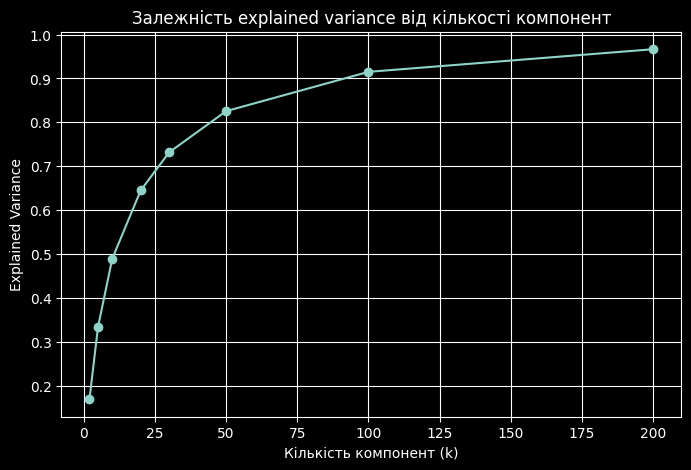

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(components_list, variance_list, marker='o')
plt.xlabel("Кількість компонент (k)")
plt.ylabel("Explained Variance")
plt.title("Залежність explained variance від кількості компонент")
plt.grid(True)
plt.show()